# DreamerV1 — Visual Experiments

> **Goal:** Feel why learning behaviour *in imagination* with analytic value gradients works — the core of Dreamer.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Cheap imagination** | How much cheaper is rolling out in a compact latent than in pixels? |
| 2 | **Analytic value gradient** | Why is backprop-through-dynamics lower variance than REINFORCE? |
| 3 | **λ-returns** | How does λ trade bias against variance in the value target? |
| 4 | **Learning in a dream** | Can a controller be learned purely by backprop through an imagined rollout? |

---
**Linked theory:** [research/01-dreamerv1.md](../research/01-dreamerv1.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(0)
np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete. torch', torch.__version__)

Setup complete. torch 2.12.0+cu130


---
## Experiment 1: Cheap imagination

**Question:** Dreamer imagines thousands of trajectories. It can afford this because rollouts happen in a compact latent state, not in pixels. How big is the gap?

We compare the per-step cost of a pixel-space rollout ($O(H\cdot W\cdot C)$) against a latent rollout ($O(d)$) across image resolutions.

In [2]:
resolutions = np.array([16, 32, 64, 128, 256])
C = 3
d_latent = 230   # typical Dreamer latent: 200 deterministic + 30 stochastic
pixel_cost = resolutions ** 2 * C
latent_cost = np.full_like(pixel_cost, d_latent)
print('pixel dims:', pixel_cost)
print('latent dim:', d_latent, '-> speedup at 256px:', pixel_cost[-1] // d_latent, 'x')

pixel dims: [   768   3072  12288  49152 196608]
latent dim: 230 -> speedup at 256px: 854 x


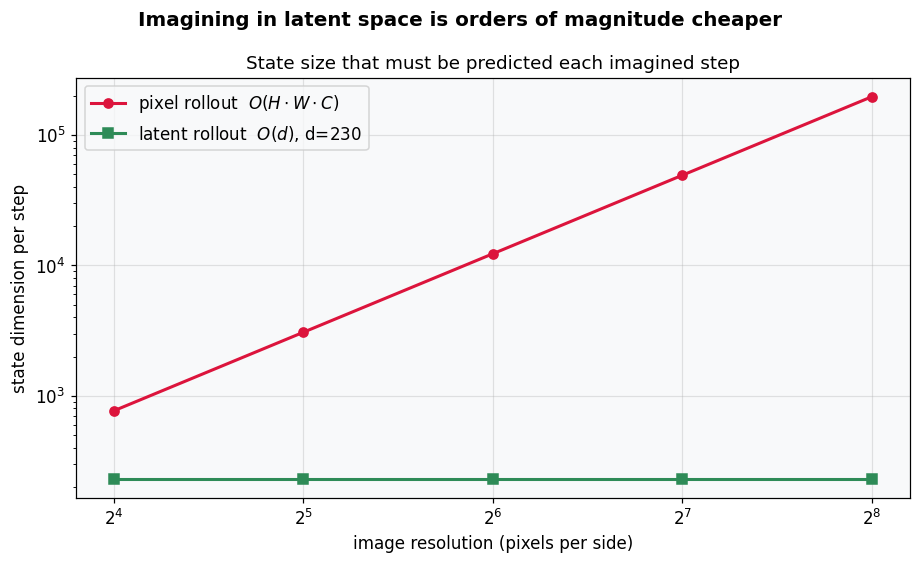

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
fig.suptitle('Imagining in latent space is orders of magnitude cheaper', fontsize=13, fontweight='bold')

ax.plot(resolutions, pixel_cost, '-o', color='crimson', lw=2, label='pixel rollout  $O(H\\cdot W\\cdot C)$')
ax.plot(resolutions, latent_cost, '-s', color='seagreen', lw=2, label=f'latent rollout  $O(d)$, d={d_latent}')
ax.set_xlabel('image resolution (pixels per side)'); ax.set_ylabel('state dimension per step')
ax.set_yscale('log'); ax.set_xscale('log', base=2)
ax.set_title('State size that must be predicted each imagined step')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The pixel cost (red) grows quadratically with resolution and is already ~850× the latent cost at 256px, while the latent cost (green) is flat — the latent dimension does not depend on image size.
2. **Why it looks this way:** A pixel rollout must predict every pixel each step; a latent rollout predicts only the compact RSSM state. Decoding to pixels is needed only when you actually want to *look*, not to imagine and plan.
3. **Key takeaway:** This cost gap is what lets Dreamer dream thousands of trajectories per update — the foundation of its data efficiency.

---
## Experiment 2: Analytic value gradient

**Question:** Dreamer trains the actor by backpropagating value gradients *through* the differentiable dynamics, instead of the score-function (REINFORCE) estimator. Why does that help?

For a Gaussian policy $a=\theta+\sigma\varepsilon$ and a differentiable reward $J(a)=-(a-a^*)^2$, both the pathwise (reparameterized) and the score-function estimators are unbiased. We compare their *variance* across single samples.

In [4]:
torch.manual_seed(1)

theta0, sigma, a_star = 0.5, 0.7, 2.0
true_grad = -2 * (theta0 - a_star)        # d E[J] / d theta
M = 4000

pathwise, score = [], []
for _ in range(M):
    eps = torch.randn(1)
    # pathwise: reparameterize a, backprop through reward
    th = torch.tensor([theta0], requires_grad=True)
    a = th + sigma * eps
    J = -(a - a_star) ** 2
    J.backward()
    pathwise.append(th.grad.item())
    # score-function (REINFORCE): J(a) * d log pi(a)/d theta, a detached
    a_val = (theta0 + sigma * eps).item()
    Jv = -(a_val - a_star) ** 2
    score.append(Jv * (a_val - theta0) / sigma ** 2)
pathwise, score = np.array(pathwise), np.array(score)
print(f'true gradient        : {true_grad:.3f}')
print(f'pathwise   mean/std  : {pathwise.mean():.3f} / {pathwise.std():.3f}')
print(f'score-func mean/std  : {score.mean():.3f} / {score.std():.3f}')

true gradient        : 3.000
pathwise   mean/std  : 3.016 / 1.381
score-func mean/std  : 2.983 / 6.922


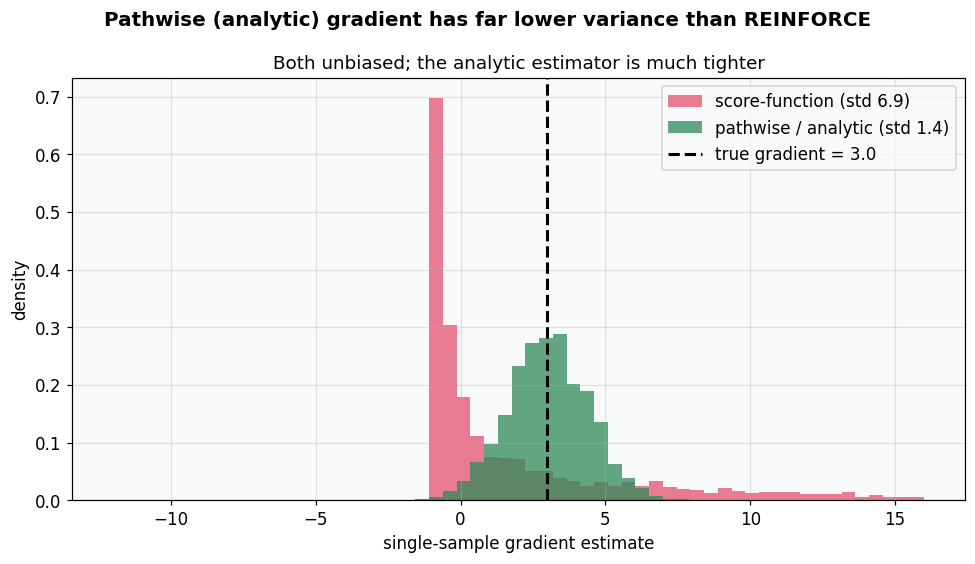

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.2))
fig.suptitle('Pathwise (analytic) gradient has far lower variance than REINFORCE', fontsize=13, fontweight='bold')

bins = np.linspace(-12, 16, 60)
ax.hist(score, bins=bins, alpha=0.55, color='crimson', density=True, label=f'score-function (std {score.std():.1f})')
ax.hist(pathwise, bins=bins, alpha=0.75, color='seagreen', density=True, label=f'pathwise / analytic (std {pathwise.std():.1f})')
ax.axvline(true_grad, color='black', ls='--', lw=2, label=f'true gradient = {true_grad:.1f}')
ax.set_xlabel('single-sample gradient estimate'); ax.set_ylabel('density')
ax.set_title('Both unbiased; the analytic estimator is much tighter')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Both histograms centre on the true gradient (dashed line), so both are unbiased — but the green pathwise estimator is a narrow spike while the red score-function estimator is broad, with a much larger spread.
2. **Why it looks this way:** The pathwise estimator uses the reward's actual slope $dJ/da$ propagated through $a$, carrying directional information; the score-function estimator only multiplies a scalar reward by a noisy log-probability gradient, throwing away that slope and inflating variance.
3. **Key takeaway:** Backpropagating value gradients through differentiable dynamics — exactly what Dreamer does over imagined rollouts — gives a low-variance learning signal, which is why it learns efficiently.

---
## Experiment 3: λ-returns

**Question:** Dreamer's critic regresses the λ-return, a weighted blend of n-step returns. How does λ trade the bias of a short bootstrap against the variance of a long rollout?

We build imagined rollouts with noisy rewards and a *biased* bootstrap value, compute the λ-return for a range of λ, and measure its bias and variance against the known true return.

In [6]:
np.random.seed(3)

H, gamma = 12, 0.95
true_reward = 1.0
true_return = sum(gamma ** t * true_reward for t in range(H))   # known ground truth
value_bias = 0.6        # bootstrap critic systematically too low
reward_noise = 0.8


def lambda_return_samples(lam, n_samples=3000):
    out = []
    for _ in range(n_samples):
        r = true_reward + reward_noise * np.random.randn(H)        # noisy imagined rewards
        # biased bootstrap value at each step (true tail discounted, scaled down)
        vboot = np.array([value_bias * sum(gamma ** k * true_reward for k in range(H - t)) for t in range(H + 1)])
        # n-step returns from t=0
        Rn = np.zeros(H)
        for n in range(1, H + 1):
            Rn[n - 1] = sum(gamma ** k * r[k] for k in range(n)) + gamma ** n * vboot[n]
        if lam == 0:
            G = Rn[0]
        else:
            w = (1 - lam) * lam ** np.arange(H - 1)
            G = (w * Rn[:-1]).sum() + lam ** (H - 1) * Rn[-1]
        out.append(G)
    return np.array(out)


lams = np.linspace(0, 0.99, 12)
bias = np.array([lambda_return_samples(l).mean() - true_return for l in lams])
std = np.array([lambda_return_samples(l).std() for l in lams])
print('true return:', round(true_return, 2))

true return: 9.19


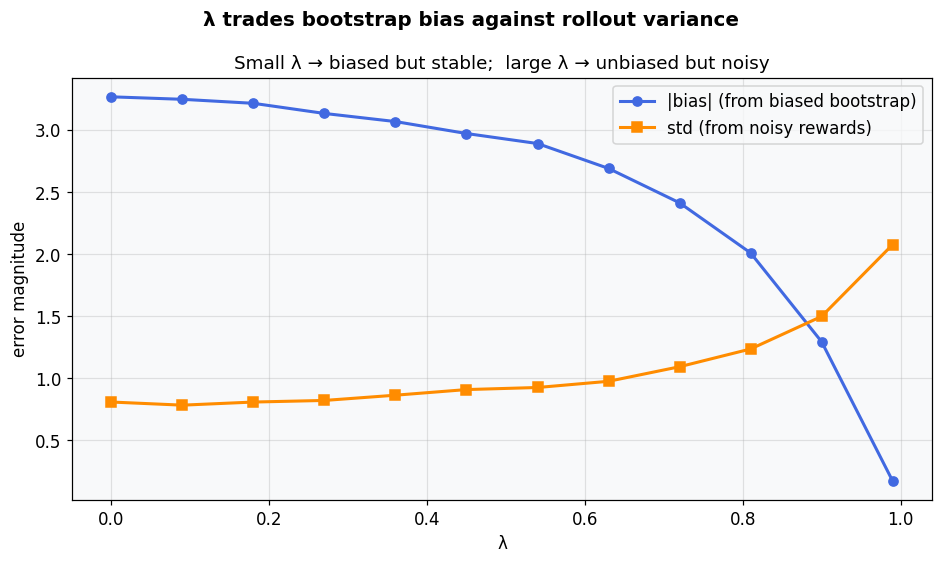

In [7]:
fig, ax = plt.subplots(figsize=(8.7, 5.2))
fig.suptitle('λ trades bootstrap bias against rollout variance', fontsize=13, fontweight='bold')

ax.plot(lams, np.abs(bias), '-o', color='royalblue', lw=2, label='|bias| (from biased bootstrap)')
ax.plot(lams, std, '-s', color='darkorange', lw=2, label='std (from noisy rewards)')
ax.set_xlabel('λ'); ax.set_ylabel('error magnitude')
ax.set_title('Small λ → biased but stable;  large λ → unbiased but noisy')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** As λ rises, the bias (blue) falls toward zero — long rollouts rely less on the biased bootstrap — while the standard deviation (orange) climbs, because long rollouts accumulate more reward noise.
2. **Why it looks this way:** λ=0 is a one-step return that leans entirely on the biased critic (low variance, high bias); λ→1 is a full Monte-Carlo return that ignores the critic (unbiased, high variance). λ-returns interpolate between these extremes.
3. **Key takeaway:** An intermediate λ (Dreamer uses ≈0.95) gives the critic a target that is mostly unbiased yet still controlled in variance — the standard bias–variance sweet spot.

---
## Experiment 4: Learning in a dream

**Question:** Can a policy be learned purely by backpropagating the return through an imagined rollout of a differentiable world model — no environment interaction during the update?

We use a tiny differentiable 1D world: a point with dynamics $x_{t+1}=x_t+a_t$, a proportional controller $a_t=\theta\,(c-x_t)$, and reward $-(x_t-c)^2-0.01a_t^2$. We learn the gain θ by gradient ascent on the imagined return (autograd through the rollout).

In [8]:
torch.manual_seed(4)

H, target, x0 = 20, 1.0, -1.0


def imagined_return(theta):
    x = torch.tensor(x0)
    R = torch.tensor(0.0)
    for _ in range(H):
        a = theta * (target - x)
        x = x + a
        R = R - (x - target) ** 2 - 0.01 * a ** 2
    return R


theta = torch.tensor([0.05], requires_grad=True)
opt = torch.optim.Adam([theta], lr=0.05)
hist_theta, hist_R = [], []
for it in range(120):
    opt.zero_grad()
    loss = -imagined_return(theta)          # maximize return = minimize negative
    loss.backward()                         # analytic gradient THROUGH the rollout
    opt.step()
    hist_theta.append(theta.item()); hist_R.append(-loss.item())

# trajectories before / after learning
def rollout(th):
    x, xs = x0, [x0]
    for _ in range(H):
        x = x + th * (target - x); xs.append(x)
    return xs

before, after = rollout(hist_theta[0]), rollout(theta.item())
print(f'gain θ: {hist_theta[0]:.3f} -> {theta.item():.3f},  return {hist_R[0]:.1f} -> {hist_R[-1]:.1f}')

gain θ: 0.100 -> 0.822,  return -32.3 -> -0.2


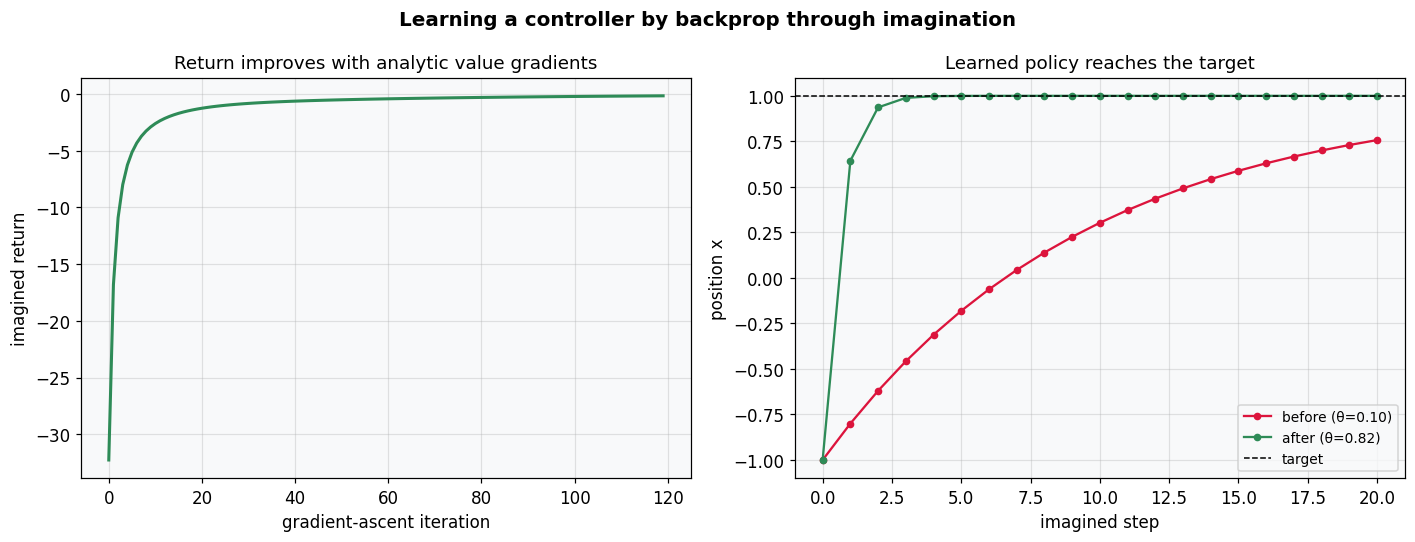

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Learning a controller by backprop through imagination', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(hist_R, color='seagreen', lw=2)
ax.set_xlabel('gradient-ascent iteration'); ax.set_ylabel('imagined return')
ax.set_title('Return improves with analytic value gradients')

ax2 = axes[1]
ax2.plot(before, '-o', ms=4, color='crimson', label=f'before (θ={hist_theta[0]:.2f})')
ax2.plot(after, '-o', ms=4, color='seagreen', label=f'after (θ={theta.item():.2f})')
ax2.axhline(target, color='black', ls='--', lw=1, label='target')
ax2.set_xlabel('imagined step'); ax2.set_ylabel('position x')
ax2.set_title('Learned policy reaches the target')
ax2.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The imagined return climbs and plateaus (left) as the controller gain is tuned; the learned policy (green, right) drives the point smoothly to the target, while the initial weak gain (red) barely moves it.
2. **Why it looks this way:** Because every step of the rollout is differentiable, autograd propagates the return's gradient all the way back to θ — a direct, low-variance signal that says exactly how to change the policy. No environment steps were taken during these updates.
3. **Key takeaway:** This is Dreamer in miniature: a behaviour learned entirely inside a differentiable world model by backpropagating value gradients through imagined trajectories.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Cheap imagination | Latent rollouts cost $O(d)$ vs $O(HWC)$ for pixels, enabling thousands of imagined trajectories. |
| 2. Analytic value gradient | Backprop-through-dynamics is unbiased *and* far lower variance than REINFORCE. |
| 3. λ-returns | λ blends biased bootstraps and noisy rollouts; ≈0.95 balances bias and variance. |
| 4. Learning in a dream | A policy can be learned purely by differentiating the return through an imagined rollout. |

### Connection to the broader theory

DreamerV1 assembles the [RSSM](../../06-latent-temporal/research/04-rssm-recurrent-state-space-model.md), [value learning](../../07-latent-planning/research/03-value-function-in-latent.md), and [imagined policy gradients](../../07-latent-planning/research/07-policy-gradient-imagined-dreamer.md) into the first complete latent world-model agent. Its reliance on pixel reconstruction is the weak point the lineage then attacks: **DreamerV2** moves to discrete latents for stability, and **DreamerV3** adds KL balancing and symlog to scale across many domains.